In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import os
os.chdir(r'G:\My Drive\Study\Time Series Analysis Udemy\Data\time series analysis forecasting')
os.getcwd()

'G:\\My Drive\\Study\\Time Series Analysis Udemy\\Data\\time series analysis forecasting'

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

In [3]:
import statsmodels.api as sm

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf

from statsmodels.tsa.statespace.varmax import VARMAX
from statsmodels.tsa.api import VAR


# Data preprocessing

In [4]:
df = pd.read_csv('temperature.csv')

In [5]:
df.head()

,record_id,month,day,year,AverageTemperatureFahr,AverageTemperatureUncertaintyFahr,City,country_id,Country,Latitude,Longitude
0,474376,1,1,1853,NaN,NaN,Auckland,NEW,New Zealand,36.17S,175.03E
1,474377,2,1,1853,NaN,NaN,Auckland,NEW,New Zealand,36.17S,175.03E
2,474378,3,1,1853,NaN,NaN,Auckland,NEW,New Zealand,36.17S,175.03E
3,474379,4,1,1853,NaN,NaN,Auckland,NEW,New Zealand,36.17S,175.03E
4,474380,5,1,1853,NaN,NaN,Auckland,NEW,New Zealand,36.17S,175.03E


In [8]:
''' the format we would want is T*D, for simplicity, we would be using D=2, i.e; 2 cities'''

' the format we would want is T*D, for simplicity, we would be using D=2, i.e; 2 cities'

In [6]:
def parse_date(row):
    s = f"{row['year']}-{row['month']}-{row['day']}"
    return datetime.strptime(s, "%Y-%m-%d")

In [7]:
df['Date'] = df.apply(parse_date, axis = 1)

In [9]:
auckland = df[df['City']=='Auckland'].copy().dropna()
stockholm = df[df['City']=='Stockholm'].copy().dropna() #removing missing values if any

In [12]:
auckland =  auckland[['Date','AverageTemperatureFahr']].copy()
stockholm = stockholm[['Date','AverageTemperatureFahr']].copy()

In [16]:
auckland.set_index(auckland['Date'], inplace = True)
auckland.drop('Date', axis = 1, inplace = True)
auckland.columns = ['AucklandTemp']

In [17]:
auckland.head()

,AucklandTemp
Date,
1853-06-01,51.9062
1853-07-01,52.3886
1853-08-01,52.8530
1853-09-01,52.5776
1853-10-01,54.8726


In [18]:
stockholm.set_index(stockholm['Date'], inplace = True)
stockholm.drop('Date', axis = 1, inplace = True)
stockholm.columns = ['StockholmTemp']

In [19]:
stockholm.head()

,StockholmTemp
Date,
1743-11-01,42.8414
1744-04-01,36.8888
1744-05-01,45.1220
1744-06-01,53.1824
1744-07-01,60.0260


In [20]:
joined = auckland.join(stockholm, how ='outer') #has some missing data 

In [22]:
joined.head()

,AucklandTemp,StockholmTemp
Date,,
1743-11-01,NaN,42.8414
1744-04-01,NaN,36.8888
1744-05-01,NaN,45.1220
1744-06-01,NaN,53.1824
1744-07-01,NaN,60.0260


In [24]:
joined.shape

(3155, 2)

In [26]:
# limiting the data for training to be just 500 since 3000 is too big for VARMA to handle
joined_part = joined.iloc[-500:].copy()
joined_part.index.freq ='MS'

In [29]:
joined_part.isna().sum()

AucklandTemp     1
StockholmTemp    4
dtype: int64

In [30]:
joined_part.head()

,AucklandTemp,StockholmTemp
Date,,
1972-01-01,64.7312,27.9194
1972-02-01,65.2010,31.8020
1972-03-01,67.2116,33.3140
1972-04-01,62.6378,37.1462
1972-05-01,58.4708,44.9906


In [31]:
''' dont do this for stock prices '''
joined_part.interpolate(inplace = True)

In [33]:
joined_part.isna().sum()

AucklandTemp     0
StockholmTemp    0
dtype: int64

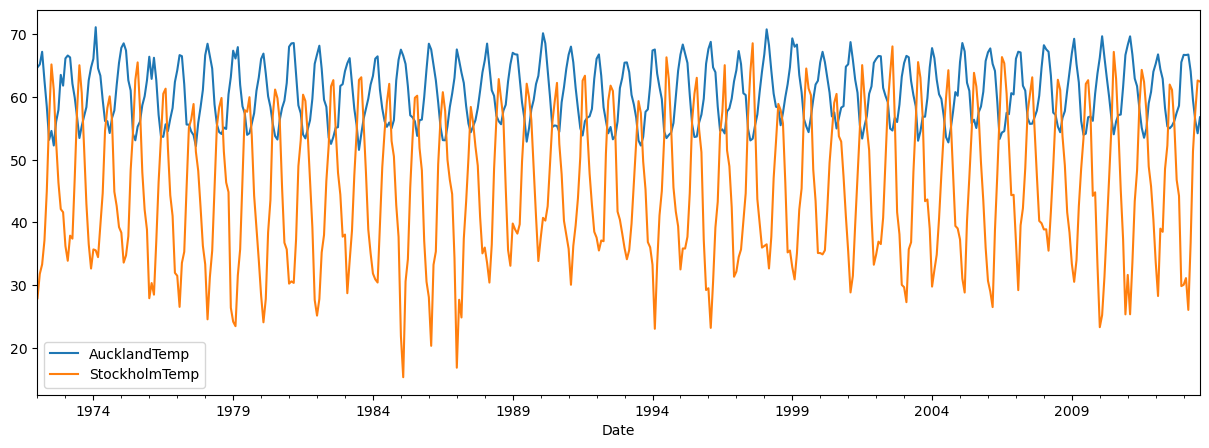

In [34]:
joined_part.plot(figsize = (15,5));

In [35]:
'''temperature of both these cities not on the same scale - so better to scale both the data '''

'temperature of both these cities not on the same scale - so better to scale both the data '

In [37]:
Ntest = 12 # this represents 1 year
train = joined_part.iloc[:-Ntest].copy()
test = joined_part.iloc[-Ntest:].copy()

In [38]:
# temperatures are not on the same scale, hence scaling both 
scaler_auckland = StandardScaler()
train['ScaledAuckland'] = scaler_auckland.fit_transform(train[['AucklandTemp']])
test['ScaledAuckland'] = scaler_auckland.transform(test[['AucklandTemp']])

In [39]:
scaler_stockholm = StandardScaler()
train['ScaledStockholm'] = scaler_stockholm.fit_transform(train[['StockholmTemp']])
test['ScaledStockholm']= scaler_stockholm.transform(test[['StockholmTemp']])

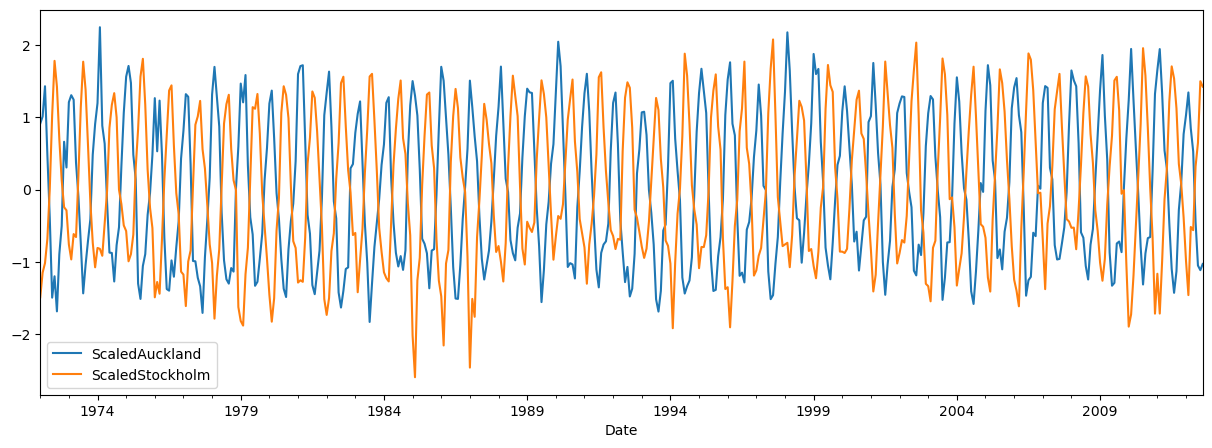

In [44]:
train[['ScaledAuckland','ScaledStockholm']].plot(figsize = (15,5));

In [45]:
train_idx = joined_part.index <= train.index[-1]
test_idx = joined_part.index > train.index[-1]

In [47]:
## putting this back in the original dataframe
joined_part.loc[train_idx,'ScaledAuckland'] = train['ScaledAuckland']
joined_part.loc[test_idx,'ScaledAuckland'] = test['ScaledAuckland']

joined_part.loc[train_idx,'ScaledStockholm'] = train['ScaledStockholm']
joined_part.loc[test_idx,'ScaledStockholm'] = test['ScaledStockholm']

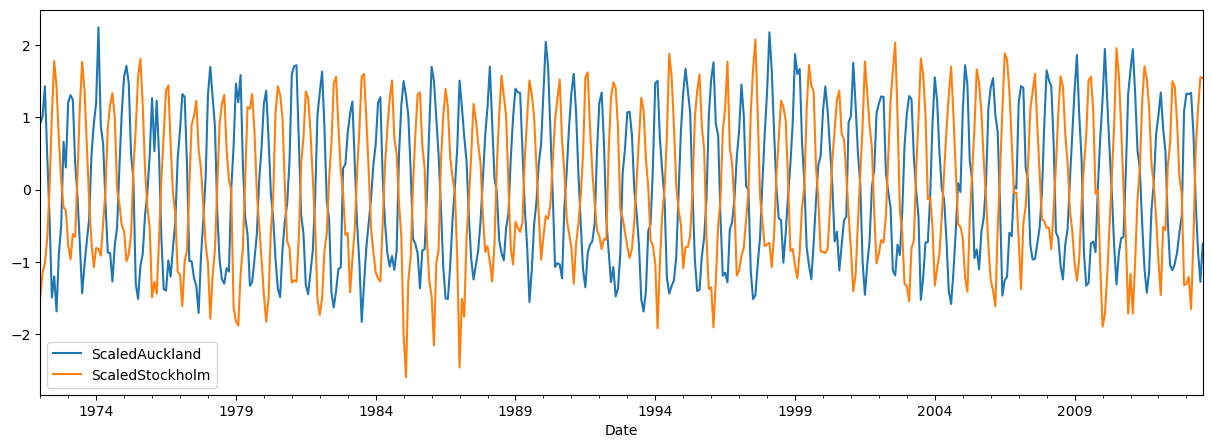

In [48]:
joined_part[['ScaledAuckland','ScaledStockholm']].plot(figsize = (15,5));

In [50]:
''' this already looks quite stationary but lets check anyways. in VARMA model, it is our responsibility to feed it stationary data for
both the time seres manually. there is no VARIMA'''

' this already looks quite stationary but lets check anyways. in VARMA model, it is our responsibility to feed it stationary data for\nboth the time seres manually. there is no VARIMA'

In [51]:
adfuller(train['ScaledAuckland'])

(np.float64(-4.633063227339951),
 np.float64(0.00011220810248640759),
 18,
 469,
 {'1%': np.float64(-3.444370153876086),
  '5%': np.float64(-2.867722323562515),
  '10%': np.float64(-2.5700629410213627)},
 np.float64(193.92851069569087))

In [52]:
adfuller(train['ScaledStockholm'])

(np.float64(-3.768535012092378),
 np.float64(0.003246156776234799),
 14,
 473,
 {'1%': np.float64(-3.444250937448703),
  '5%': np.float64(-2.867669873870454),
  '10%': np.float64(-2.5700349866579657)},
 np.float64(182.1341599835107))

In [53]:
'''both quite stationary'''

'both quite stationary'

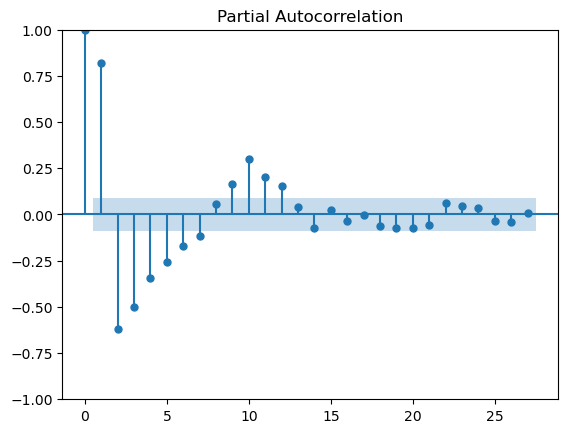

In [55]:
plot_pacf(train['ScaledAuckland']);

In [56]:
''' lags closer to 0 are more significant'''

' lags closer to 0 are more significant'

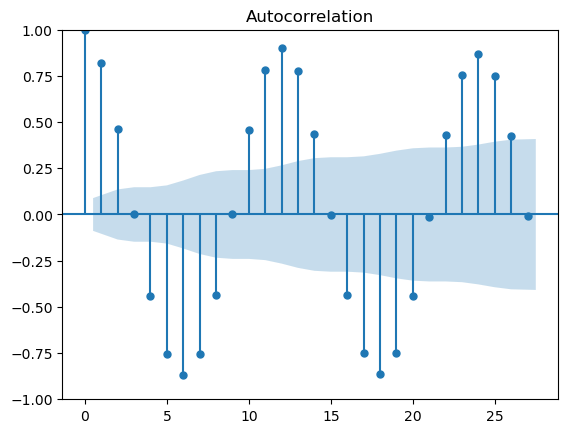

In [57]:
plot_acf(train['ScaledAuckland']);

In [64]:
'''seeing strong seasonal pattern in acf as present in the data'''

'seeing strong seasonal pattern in acf as present in the data'

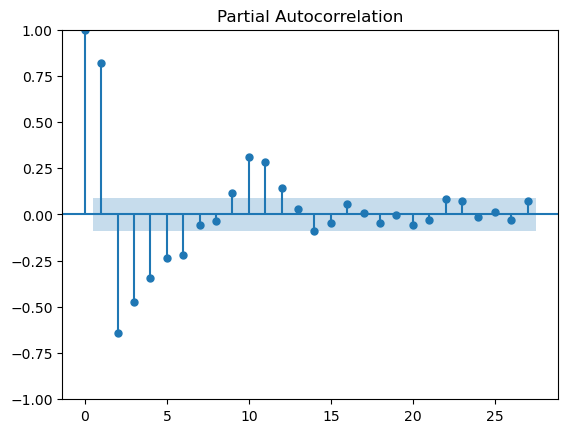

In [59]:
plot_pacf(train['ScaledStockholm']);

In [61]:
'''similar pattern'''

'similar pattern'

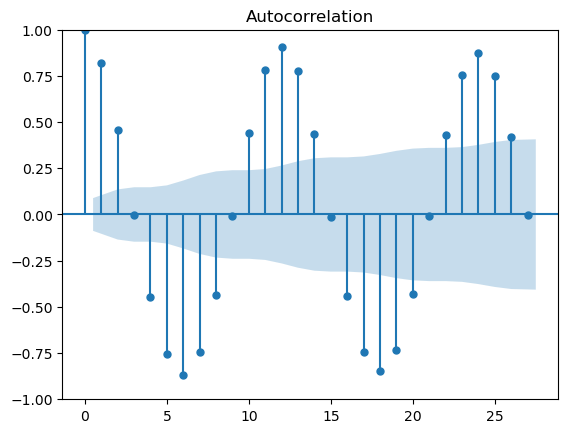

In [66]:
plot_acf(train['ScaledStockholm']);

In [67]:
'''again same seasonal patten in acf'''

'again same seasonal patten in acf'

# VARMA

In [65]:
cols = ['ScaledAuckland','ScaledStockholm']
t0 = datetime.now() # to measure the time taken to run this model- varmax takes a lot of time
model = VARMAX(train[cols], order =(10,10)) # selected these orders for no particular reason
print("executed first line")
res =  model.fit(maxiter = 100)
print("Duration:", datetime.now() - t0)

C:\Users\VARUN\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'


executed first line


C:\Users\VARUN\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Duration: 0:02:49.157869


In [69]:
''' as mentioned in the notes, VARMAX has identifiability issues, i.e, multiple combinations of parameters theta and phi for similar results, meaning 
solution is not unique.
there is also a failed to converge model since the number of parameters are very high - in this case, it is 2(10*4+2) = 84. we can try using smaller orders
like (2,0) etc or increase the max_iter to say 500 etc.
hence, VAR is used more often'''

' as mentioned in the notes, VARMAX has identifiability issues, i.e, multiple combinations of parameters theta and phi for similar results, meaning \nsolution is not unique.\nthere is also a failed to converge model since the number of parameters are very high - in this case, it is 2(10*4+2) = 84. we can try using smaller orders\nlike (2,0) etc or increase the max_iter to say 500 etc.\nhence, VAR is used more often'

In [70]:
fcast = res.get_forecast(Ntest)

In [75]:
fcast.predicted_mean

,ScaledAuckland,ScaledStockholm
2012-09-01,-0.902710,0.880883
2012-10-01,-0.557486,0.362899
2012-11-01,0.120225,-0.312242
2012-12-01,0.775410,-0.812887
2013-01-01,1.388158,-1.226608
2013-02-01,1.415403,-1.184542
2013-03-01,1.181869,-0.974919
2013-04-01,0.385746,-0.444168
2013-05-01,-0.287486,0.268389
2013-06-01,-0.873519,1.035127


In [73]:
res.fittedvalues # insample predictions

,ScaledAuckland,ScaledStockholm
Date,,
1972-01-01,-0.002476,-0.003768
1972-02-01,0.832488,-1.093572
1972-03-01,0.719766,-0.735298
1972-04-01,0.814014,-0.605295
1972-05-01,-0.081828,0.011614
...,...,...
2012-04-01,0.520914,-0.246033
2012-05-01,-0.289756,0.329957
2012-06-01,-1.064115,1.128180


In [76]:
joined_part.loc[train_idx, 'Train Pred Auckland'] = res.fittedvalues['ScaledAuckland']
joined_part.loc[test_idx, 'Test Pred Auckland'] = fcast.predicted_mean['ScaledAuckland']

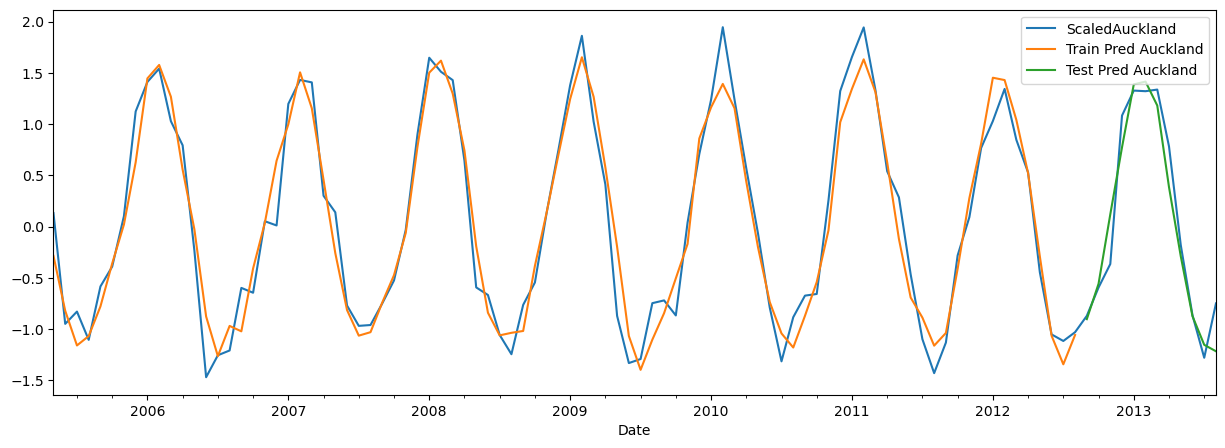

In [79]:
plot_cols = ['ScaledAuckland','Train Pred Auckland','Test Pred Auckland']
joined_part.iloc[-100:][plot_cols].plot(figsize = (15,5)); 
# plotting last 100 months of total data which includes 12 months of test data displayed at the end

In [80]:
''' looks pretty good'''

' looks pretty good'

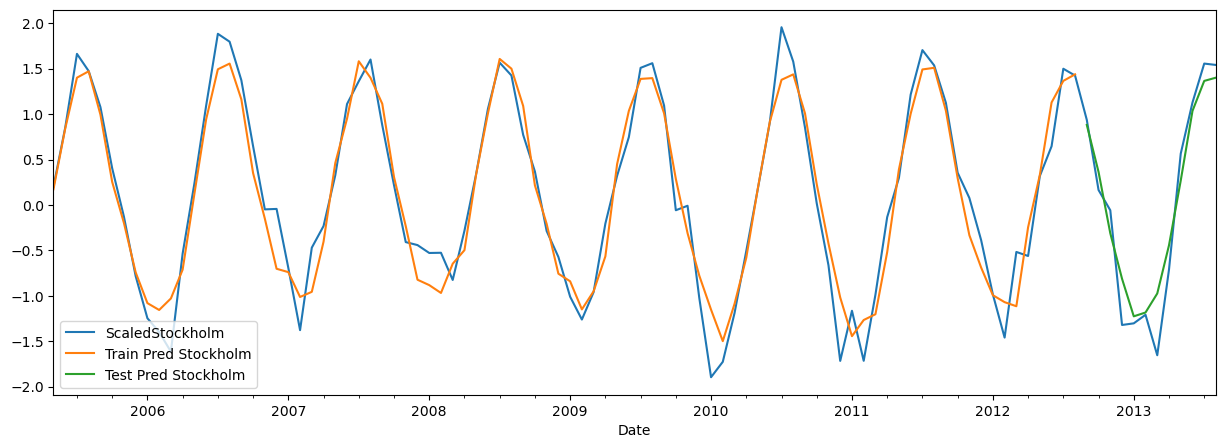

In [81]:
joined_part.loc[train_idx, 'Train Pred Stockholm'] = res.fittedvalues['ScaledStockholm']
joined_part.loc[test_idx, 'Test Pred Stockholm'] = fcast.predicted_mean['ScaledStockholm']

plot_cols = ['ScaledStockholm','Train Pred Stockholm','Test Pred Stockholm']
joined_part.iloc[-100:][plot_cols].plot(figsize = (15,5)); 
# plotting last 100 months of total data which includes 12 months of test data displayed at the end

In [88]:
y_true = joined_part.loc[train_idx, 'ScaledAuckland']
y_pred = joined_part.loc[train_idx, 'Train Pred Auckland']
print("Auckland  Train R^2", r2_score(y_true, y_pred))

y_true = joined_part.loc[test_idx, 'ScaledAuckland']
y_pred = joined_part.loc[test_idx, 'Test Pred Auckland']
print("Auckland  Test R^2", r2_score(y_true, y_pred))

Auckland  Train R^2 0.9294589605331688
Auckland  Test R^2 0.9311544198231477


In [89]:
''' pretty good'''

' pretty good'

In [90]:
y_true = joined_part.loc[train_idx, 'ScaledStockholm']
y_pred = joined_part.loc[train_idx, 'Train Pred Stockholm']
print("Auckland  Train R^2", r2_score(y_true, y_pred))

y_true = joined_part.loc[test_idx, 'ScaledStockholm']
y_pred = joined_part.loc[test_idx, 'Test Pred Stockholm']
print("Auckland  Test R^2", r2_score(y_true, y_pred))

Auckland  Train R^2 0.9247676491056839
Auckland  Test R^2 0.9314210830909896


### conclusion VARMA model - non identifiable and takes longer to train

# VAR model

In [91]:
cols

['ScaledAuckland', 'ScaledStockholm']

In [92]:
model = VAR(train[cols]) # as explained in notes, we dont pass in the p values in this -  VAR model is like auto arima 
# we are not allowed to enter custom p values in VAR model

In [96]:
lag_order_results = model.select_order(maxlags=15) # maxlags = 15 arbitrarily choosen
lag_order_results

In [97]:
lag_order_results.selected_orders

{'aic': np.int64(12),
 'bic': np.int64(6),
 'hqic': np.int64(11),
 'fpe': np.int64(12)}

In [103]:
'''best aic achieved with p = 12, best bic achieved with p = 6. helps to have a look at the best p for diff criterion'''
''' .select_order is not necessary, it is just for information only'''

' .select_order is not necessary, it is just for information only'

In [100]:
results = model.fit(maxlags=15, ic ='aic')

In [101]:
lag_order = results.k_ar

In [102]:
lag_order

12

In [107]:
results.fittedvalues

,ScaledAuckland,ScaledStockholm
Date,,
1973-01-01,1.131929,-0.862152
1973-02-01,1.378058,-1.013430
1973-03-01,1.065625,-0.890386
1973-04-01,0.476984,-0.411676
1973-05-01,-0.394570,0.224029
...,...,...
2012-04-01,0.581007,-0.153746
2012-05-01,-0.096826,0.258002
2012-06-01,-0.862746,1.031408


In [104]:
prior = train.iloc[-lag_order:][cols].to_numpy() # prior is needed in numpy only since this is what is supported in the next line
fcast = results.forecast(prior, Ntest)

In [105]:
fcast

array([[-0.86491205,  0.9126215 ],
       [-0.46098815,  0.41187248],
       [ 0.06315052, -0.18716887],
       [ 0.67626557, -0.76482676],
       [ 1.14208172, -1.07130218],
       [ 1.22700523, -1.0937979 ],
       [ 0.9794002 , -0.80403685],
       [ 0.41338843, -0.40868501],
       [-0.20952007,  0.21598454],
       [-0.78821337,  0.85620681],
       [-1.10693186,  1.24994289],
       [-1.13507881,  1.24097996]])

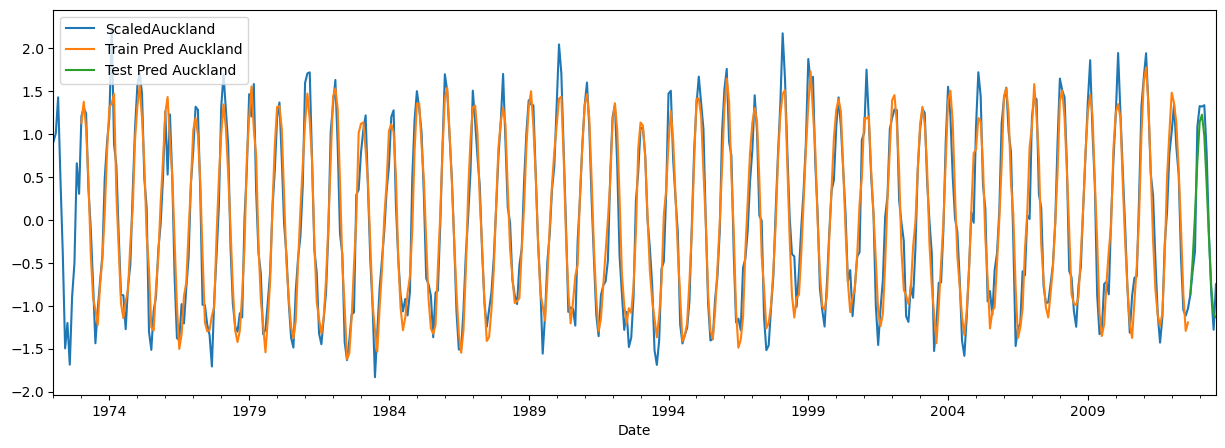

In [108]:
joined_part.loc[train_idx , 'Train Pred Auckland'] = results.fittedvalues['ScaledAuckland']
joined_part.loc[test_idx , 'Test Pred Auckland'] = fcast[:,0]

plot_cols = ['ScaledAuckland','Train Pred Auckland','Test Pred Auckland']
joined_part[plot_cols].plot(figsize = (15,5));

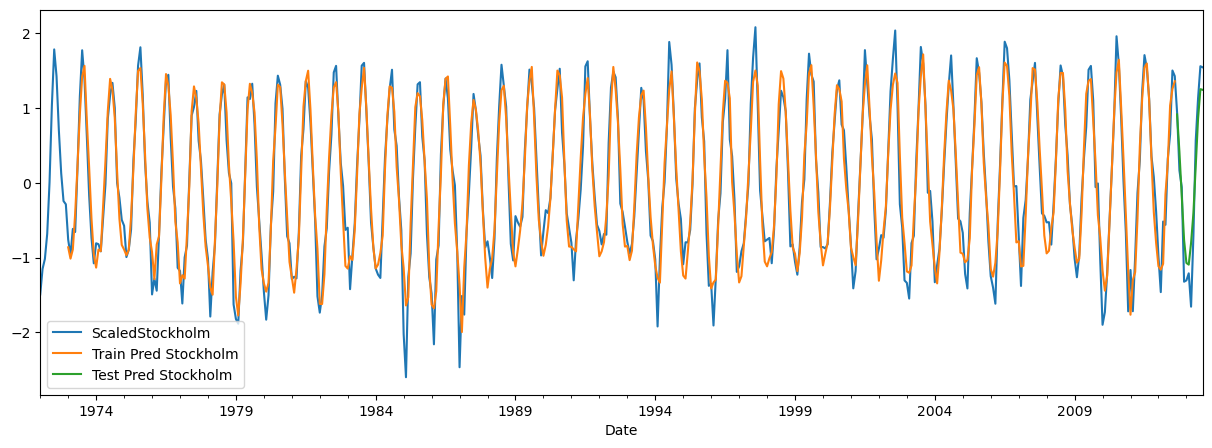

In [109]:
joined_part.loc[train_idx , 'Train Pred Stockholm'] = results.fittedvalues['ScaledStockholm']
joined_part.loc[test_idx , 'Test Pred Stockholm'] = fcast[:,1]

plot_cols = ['ScaledStockholm','Train Pred Stockholm','Test Pred Stockholm']
joined_part[plot_cols].plot(figsize = (15,5));

In [114]:
y_true = joined_part.loc[train_idx, 'ScaledAuckland']
y_pred = joined_part.loc[train_idx, 'Train Pred Auckland']
y_true = y_true[lag_order:] # doing this since VAR is not state space model like VARMAX and the 1st 12 values are nans
y_pred = y_pred[lag_order:]
print("Auckland Train R^2", r2_score (y_true, y_pred))

y_true = joined_part.loc[test_idx, 'ScaledAuckland']
y_pred = joined_part.loc[test_idx, 'Test Pred Auckland']
print("Auckland Test R^2", r2_score (y_true, y_pred))      

Auckland Train R^2 0.921070700106029
Auckland Test R^2 0.9233643831340894


In [115]:
''' for aucland , VAr is not as good as VARMA'''

' for aucland , VAr is not as good as VARMA'

In [116]:
y_true = joined_part.loc[train_idx, 'ScaledStockholm']
y_pred = joined_part.loc[train_idx, 'Train Pred Stockholm']
y_true = y_true[lag_order:] # doing this since VAR is not state space model like VARMAX and the 1st 12 values are nans
y_pred = y_pred[lag_order:]
print("Stockholm Train R^2", r2_score (y_true, y_pred))

y_true = joined_part.loc[test_idx, 'ScaledStockholm']
y_pred = joined_part.loc[test_idx, 'Test Pred Stockholm']
print("Stockholm Test R^2", r2_score (y_true, y_pred))    

Stockholm Train R^2 0.9267030553588321
Stockholm Test R^2 0.8930437688204876


In [117]:
''' for stockholm also, VAR is also not as good as VARMA'''

' for stockholm also, VAR is also not as good as VARMA'

# ARIMA for baseline

In [118]:
from statsmodels.tsa.arima.model import ARIMA

In [119]:
cols

['ScaledAuckland', 'ScaledStockholm']

In [121]:
for col in cols:
    model = ARIMA(train[col], order=(10,0,10)) ## orders are same as that of VARMA, but they have fewer paramaters since they dont contain cross terms
    res = model.fit()
    fcast = res.get_forecast(Ntest)
    print(f"{col} Train R^2:", r2_score(joined_part.loc[train_idx, col], res.fittedvalues))
    print(f"{col} Test R^2:", r2_score(joined_part.loc[test_idx, col], fcast.predicted_mean))

C:\Users\VARUN\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ScaledAuckland Train R^2: 0.9213769909874023
ScaledAuckland Test R^2: 0.9380893819743963
ScaledStockholm Train R^2: 0.9207456425973094
ScaledStockholm Test R^2: 0.9483532348040605


C:\Users\VARUN\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [124]:
'''ARIMA baseline does the best. this could be happenning since auckland in newzealand and stockholm in sweden
, and their weathers might not be affecting each other.
any correlation found out by VAR, or VARMA is just due to noise. using arima doesnt have those cross terms making it much better fit 
'''

'ARIMA baseline does the best. this could be happenning since auckland in newzealand and stockholm in sweden\n, and their weathers might not be affecting each other.\nany correlation found out by VAR, or VARMA is just due to noise. using arima doesnt have those cross terms making it much better fit \n'